In [26]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

In [27]:
df = pd.read_csv("loan_approval_data.csv")

In [28]:
df.head()
df.info()
df.isnull().sum()
# df.describe()
# df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

# Drop unnecessary column

In [29]:
df = df.drop("Applicant_ID", axis = 1)

# Drop rows with a missing target

In [30]:
df = df.dropna(subset=["Loan_Approved"]).reset_index(drop=True)

In [31]:
df.head()
# df.info()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


# EDA (Exploratory Data Analysis)

Loan_Approved
No     652
Yes    298
Name: count, dtype: int64


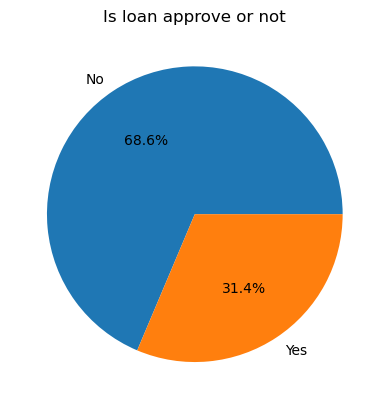

In [32]:
# How blance our class are?
classes_count = df["Loan_Approved"].value_counts().reindex(["No", "Yes"])
print(classes_count)
plt.pie(classes_count, labels=["No", "Yes"], autopct = "%1.1f%%")
plt.title("Is loan approve or not")
plt.show()

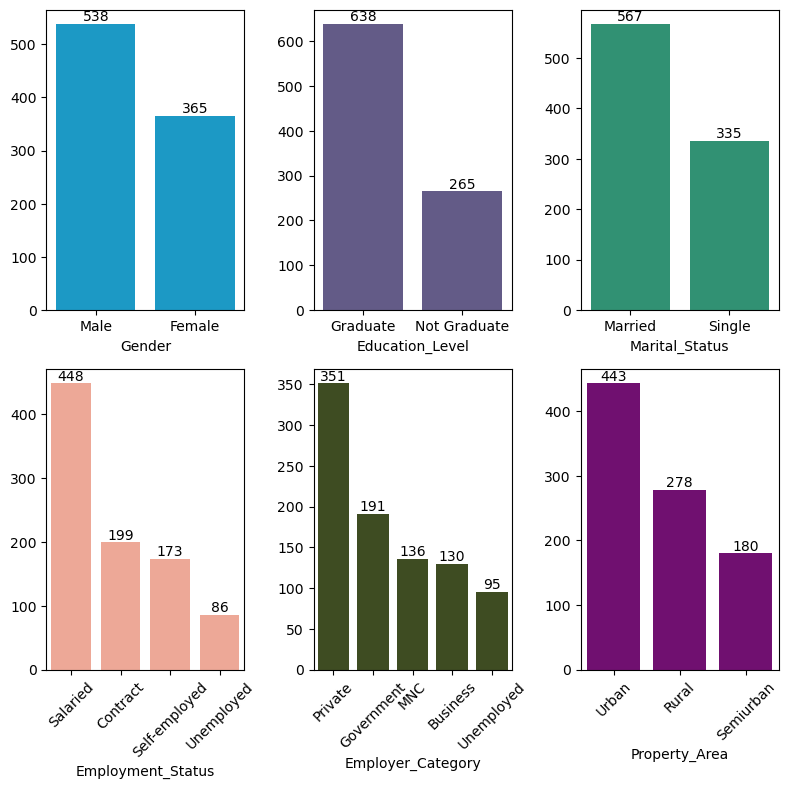

In [33]:
# Analyze Categorical data

fig, ax = plt.subplots(2, 3, figsize=(8, 8))

gender_cnt = df["Gender"].value_counts()
sns.barplot(x=gender_cnt.index, y=gender_cnt.values, ax=ax[0][0], color = "#00a7e1")
ax[0][0].bar_label(ax[0][0].containers[0])

education_cnt = df["Education_Level"].value_counts()
sns.barplot(x=education_cnt.index, y=education_cnt.values, ax=ax[0][1], color = "#5E548E")
ax[0][1].bar_label(ax[0][1].containers[0])

marital_cnt = df["Marital_Status"].value_counts()
sns.barplot(x=marital_cnt.index, y=marital_cnt.values, ax=ax[0][2], color = "#21A179")
ax[0][2].bar_label(ax[0][2].containers[0])

employment_cnt = df["Employment_Status"].value_counts()
sns.barplot(x=employment_cnt.index, y=employment_cnt.values, ax=ax[1][0], color = "#FB9F89")
ax[1][0].bar_label(ax[1][0].containers[0])
ax[1][0].tick_params(axis="x", rotation=45)

employer_cat_cnt = df["Employer_Category"].value_counts()
sns.barplot(x=employer_cat_cnt.index, y=employer_cat_cnt.values, ax=ax[1][1], color = "#40531B")
ax[1][1].bar_label(ax[1][1].containers[0])
ax[1][1].tick_params(axis="x", rotation=45)

property_cnt = df["Property_Area"].value_counts()
sns.barplot(x=property_cnt.index, y=property_cnt.values, ax=ax[1][2], color = "purple")
ax[1][2].bar_label(ax[1][2].containers[0])
ax[1][2].tick_params(axis="x", rotation=45)


plt.tight_layout()
plt.show()
# employer_cat_cnt
# ax[1][2].containers[0]

<Axes: xlabel='Coapplicant_Income', ylabel='Count'>

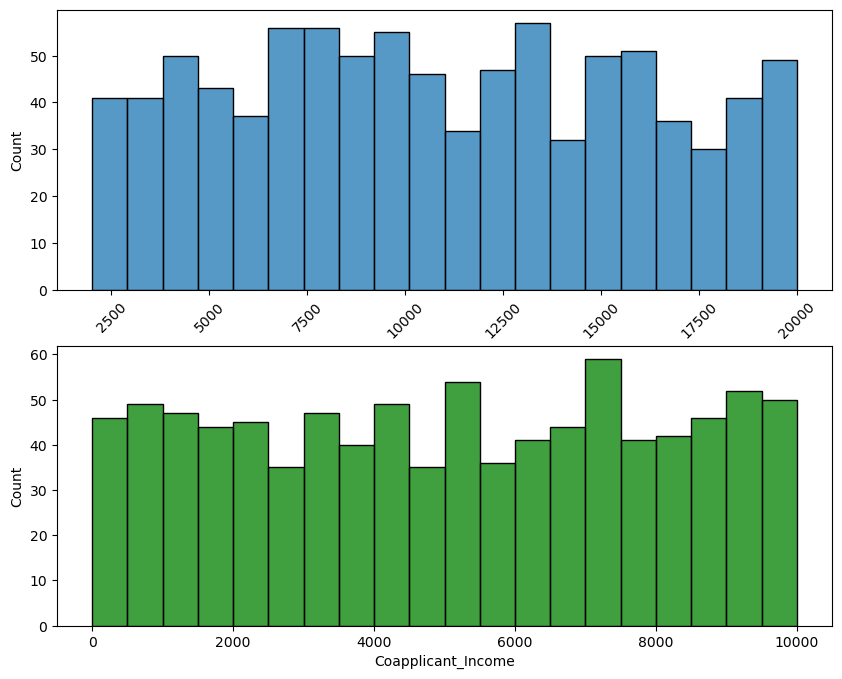

In [34]:
# Analyze income
fig, ax = plt.subplots(2, 1, figsize=(10, 8))

sns.histplot(
    data = df,
    x = "Applicant_Income",
    bins = 20,
    ax = ax[0]
)
ax[0].tick_params(axis="x", rotation=45)

sns.histplot(
    data = df,
    x = "Coapplicant_Income",
    bins = 20,
    ax = ax[1],
    color = "green"
)

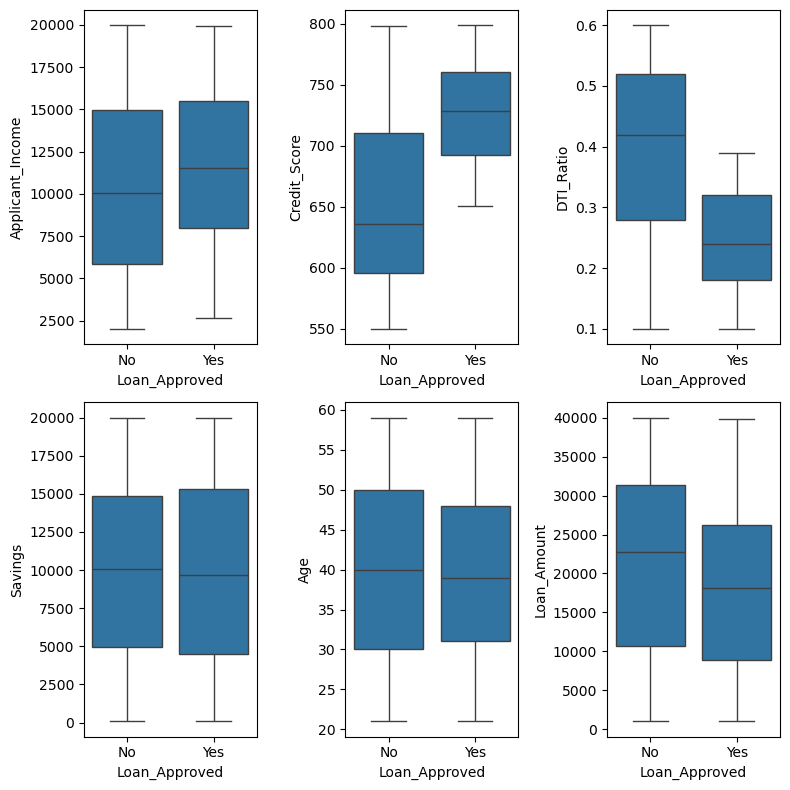

In [35]:
# OUtlier Analyis

fig, ax = plt.subplots(2, 3, figsize=(8, 8))

sns.boxplot(ax = ax[0][0], data = df, x = "Loan_Approved", y = "Applicant_Income")
sns.boxplot(ax = ax[0][1], data = df, x = "Loan_Approved", y = "Credit_Score")
sns.boxplot(ax = ax[0][2], data = df, x = "Loan_Approved", y = "DTI_Ratio")
sns.boxplot(ax = ax[1][0], data = df, x = "Loan_Approved", y = "Savings")
sns.boxplot(ax = ax[1][1], data = df, x = "Loan_Approved", y = "Age")
sns.boxplot(ax = ax[1][2], data = df, x = "Loan_Approved", y = "Loan_Amount")

plt.tight_layout()

<Axes: xlabel='Applicant_Income', ylabel='Count'>

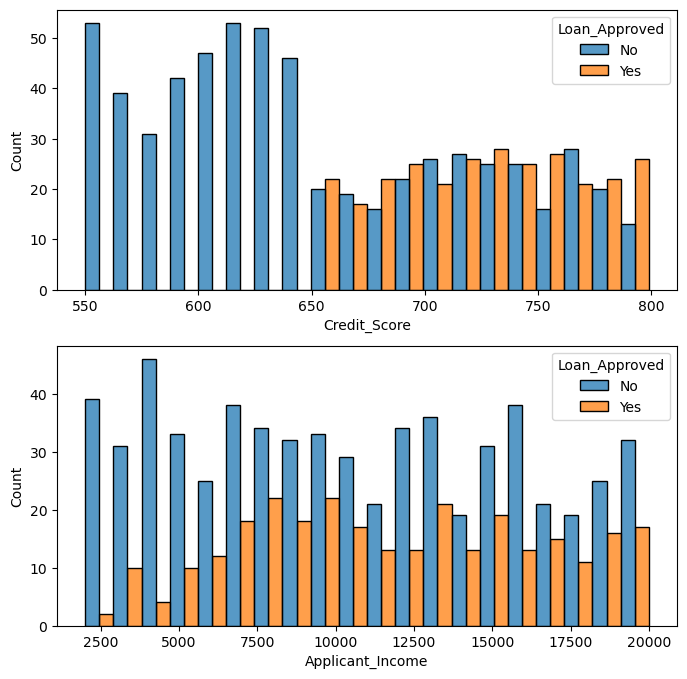

In [36]:
# Analyze Credit_Score and Applicant_Income with Loan Aprove

fig, ax = plt.subplots(2, 1, figsize=(8, 8))
sns.histplot(
    data = df,
    x = "Credit_Score",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge",
    ax = ax[0])

sns.histplot(
    data = df,
    x = "Applicant_Income",
    hue = "Loan_Approved",
    bins = 20,
    multiple = "dodge",
    ax = ax[1])

# Encode the target

In [37]:
df["Loan_Approved"] = df["Loan_Approved"].map({"No": 0, "Yes": 1}).astype(int)

# Train Test Split

In [38]:
X = df.drop(columns = "Loan_Approved")
y = df["Loan_Approved"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y
)

# Handle Missing Value

In [39]:
num_cols = X_train.select_dtypes(include = ["number"]).columns
categ_cols = X_train.select_dtypes(include = ["object"]).columns

In [40]:
# fill null value with sklearn imputer
num_imp = SimpleImputer(strategy = "mean")
X_train[num_cols] = num_imp.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imp.transform(X_test[num_cols])

cat_imp = SimpleImputer(strategy = "most_frequent")
X_train[categ_cols] = cat_imp.fit_transform(X_train[categ_cols])
X_test[categ_cols] = cat_imp.transform(X_test[categ_cols])

# Feature Encoding

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 950 entries, 0 to 949
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_Income    902 non-null    float64
 1   Coapplicant_Income  902 non-null    float64
 2   Employment_Status   906 non-null    object 
 3   Age                 902 non-null    float64
 4   Marital_Status      902 non-null    object 
 5   Dependents          903 non-null    float64
 6   Credit_Score        902 non-null    float64
 7   Existing_Loans      901 non-null    float64
 8   DTI_Ratio           903 non-null    float64
 9   Savings             901 non-null    float64
 10  Collateral_Value    901 non-null    float64
 11  Loan_Amount         903 non-null    float64
 12  Loan_Term           902 non-null    float64
 13  Loan_Purpose        902 non-null    object 
 14  Property_Area       901 non-null    object 
 15  Education_Level     903 non-null    object 
 16  Gender  

In [42]:
# Ordinal Encoder
orders = [
    ["Not Graduate", "Graduate"],
]

cols = ["Education_Level"]
oe = OrdinalEncoder(categories=orders)
X_train[cols] = oe.fit_transform(X_train[cols]).astype(int)
X_test[cols] = oe.transform(X_test[cols]).astype(int)


In [43]:
# One-Hot Encoding
cols = ["Employment_Status", "Marital_Status", "Loan_Purpose", "Property_Area", "Gender", "Employer_Category"]

ohe = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore", dtype=int)
ohe.fit(X_train[cols])

encoded_cols = ohe.get_feature_names_out(cols)

X_train[encoded_cols] = ohe.transform(X_train[cols])
X_test[encoded_cols] = ohe.transform(X_test[cols])

X_train.drop(columns=cols, inplace=True)
X_test.drop(columns=cols, inplace=True)

In [44]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
425,7486.0,9127.00000,38.0,3.000000,729.0,4.0,0.260000,9924.093923,10265.0,36198.0,...,0,1,0,0,1,1,0,0,0,0
206,7592.0,8202.00000,52.0,1.477778,553.0,3.0,0.510000,16480.000000,22080.0,13204.0,...,0,0,1,0,0,0,0,0,1,0
349,16069.0,3155.00000,47.0,2.000000,762.0,4.0,0.346612,8708.000000,49163.0,29016.0,...,0,0,0,1,0,1,0,0,0,1
745,7256.0,9654.00000,52.0,3.000000,727.0,0.0,0.370000,3083.000000,2552.0,38981.0,...,1,0,0,0,1,0,0,0,1,0
637,17745.0,5098.53417,27.0,3.000000,687.0,3.0,0.470000,17042.000000,12342.0,8641.0,...,0,0,0,0,0,0,0,1,0,0


# Correlation Heatmap

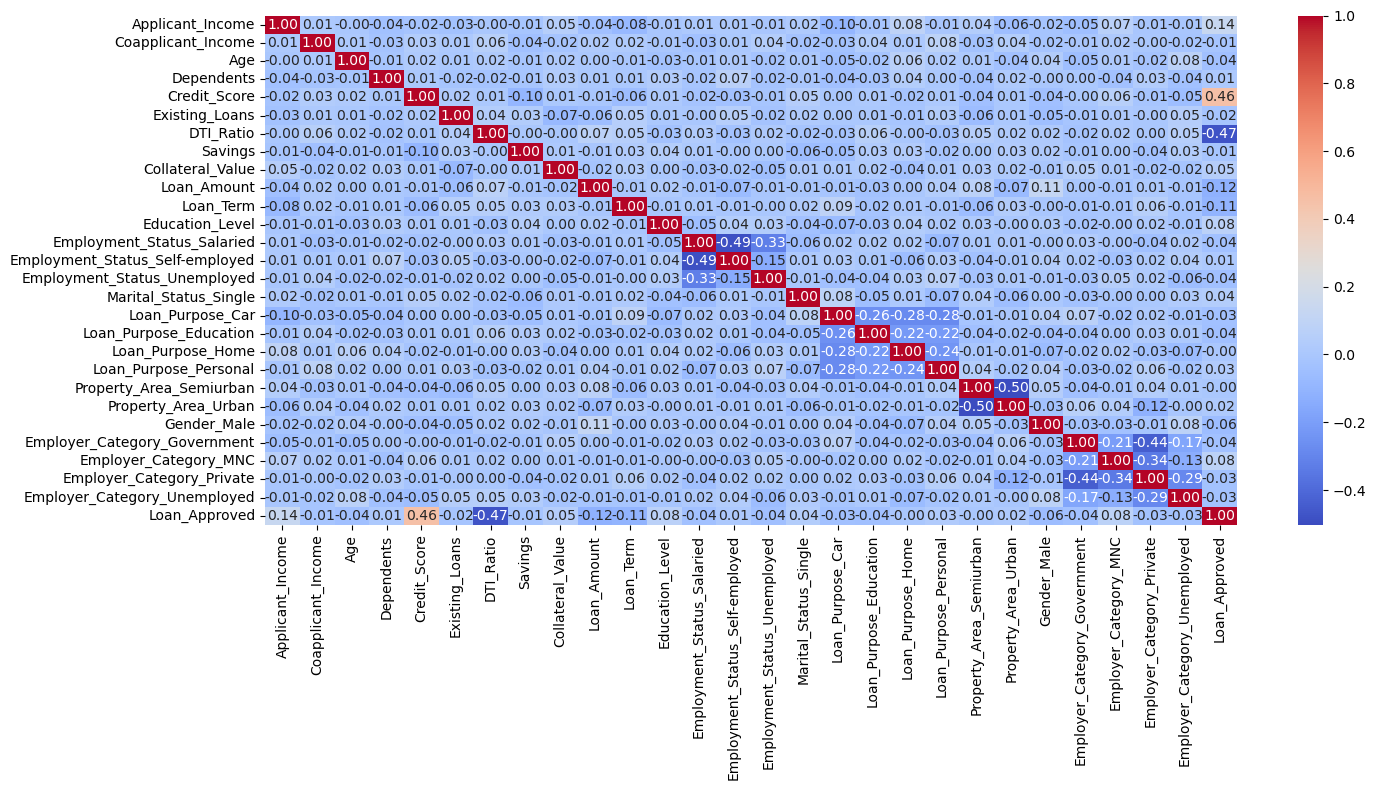

In [45]:
train_with_target = X_train.copy()
train_with_target["Loan_Approved"] = y_train

corr_matrix = train_with_target.corr()

plt.figure(figsize=(15, 8))
sns.heatmap(
    corr_matrix, 
    cmap="coolwarm", 
    annot=True, 
    fmt=".2f"
)
plt.tight_layout()
plt.show()

In [46]:
corr_matrix["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.455470
Applicant_Income                   0.135752
Employer_Category_MNC              0.083193
Education_Level                    0.075795
Collateral_Value                   0.046597
Marital_Status_Single              0.039597
Loan_Purpose_Personal              0.030815
Property_Area_Urban                0.016282
Dependents                         0.012185
Employment_Status_Self-employed    0.008099
Property_Area_Semiurban           -0.000246
Loan_Purpose_Home                 -0.002489
Coapplicant_Income                -0.010142
Savings                           -0.011500
Existing_Loans                    -0.019205
Employer_Category_Private         -0.028154
Employer_Category_Unemployed      -0.029271
Loan_Purpose_Car                  -0.034044
Employer_Category_Government      -0.035528
Employment_Status_Salaried        -0.036250
Loan_Purpose_Education            -0.040791
Employment_Status_Unemployed    

# Feature Engineering

In [47]:
X_train["Credit_Score_sq"] = X_train["Credit_Score"] ** 2
X_test["Credit_Score_sq"] = X_test["Credit_Score"] ** 2

X_train["DTI_Ratio_sq"] = X_train["DTI_Ratio"] ** 2
X_test["DTI_Ratio_sq"] = X_test["DTI_Ratio"] ** 2

# Feature Scaling

In [48]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train and Evaluate

=== Logistic Regression ===
              precision    recall  f1-score   support

          No       0.92      0.93      0.92       130
         Yes       0.84      0.82      0.83        60

    accuracy                           0.89       190
   macro avg       0.88      0.87      0.88       190
weighted avg       0.89      0.89      0.89       190

=== Gaussian Naive Bayes ===
              precision    recall  f1-score   support

          No       0.93      0.91      0.92       130
         Yes       0.81      0.85      0.83        60

    accuracy                           0.89       190
   macro avg       0.87      0.88      0.87       190
weighted avg       0.89      0.89      0.89       190

=== K-Nearest Neighbors ===
              precision    recall  f1-score   support

          No       0.86      0.93      0.90       130
         Yes       0.82      0.68      0.75        60

    accuracy                           0.85       190
   macro avg       0.84      0.81      0.82

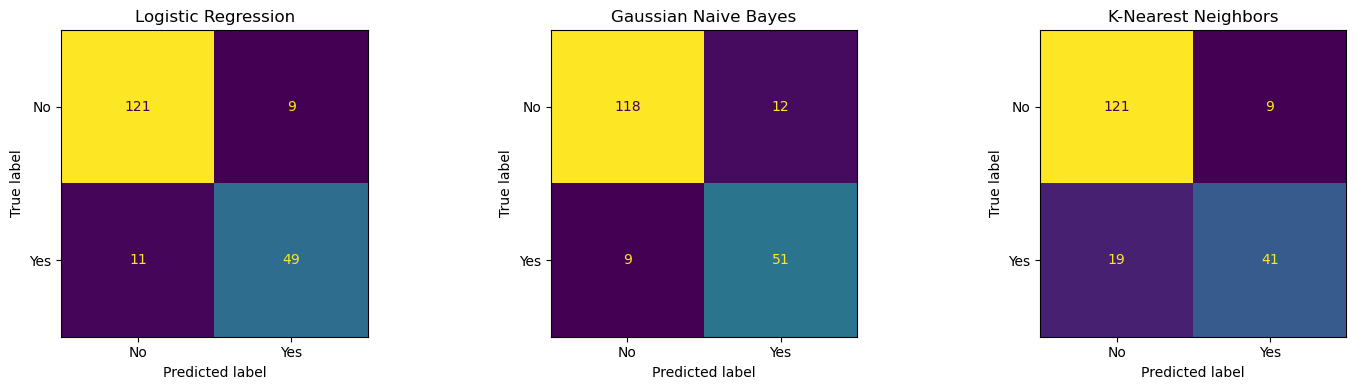

,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Logistic Regression,0.895,0.845,0.817,0.831,0.941
Gaussian Naive Bayes,0.889,0.810,0.850,0.829,0.952
K-Nearest Neighbors,0.853,0.820,0.683,0.745,0.900


In [49]:
param_grid = {
    "n_neighbors" : [3, 5, 7, 9]
}
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gaussian Naive Bayes": GaussianNB(),
    "K-Nearest Neighbors": GridSearchCV(
                                KNeighborsClassifier(),
                                param_grid,
                                cv = 5,
                                scoring = "precision"
                            ),
}
results = []

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    if hasattr(model, "predict_proba"):
        auc = roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:, 1])
    else:
        auc = np.nan

    results.append({
        "Model": name, "Accuracy": acc, "Precision": prec,
        "Recall": rec, "F1": f1, "ROC-AUC": auc
    })

    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No", "Yes"]).plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(results).set_index("Model").round(3)
results_df

# Final Model

In [50]:
final_model = models["Gaussian Naive Bayes"]

# Save all models

In [51]:
import joblib

joblib.dump(num_imp, "num_imp.pkl")
joblib.dump(cat_imp, "cat_imp.pkl")
joblib.dump(oe, "ordinal_encoder.pkl")
joblib.dump(ohe, "onehot_encoder.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(final_model, "model.pkl")

['model.pkl']